In [16]:
from tiled.client import from_profile
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt 
from datetime import datetime
import databroker
import matplotlib.ticker as ticker
# %matplotlib widget
import json


71c03eb6-c456-44c4-ab55-5f73140c7704    3 2026-03-17 14:02:24 rel_scan ['tetramm1']


/home/beams/8IDIUSER/.conda/envs/8ide_bits_test/lib/python3.11/site-packages/databroker/intake_xarray_core/base.py:23: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/tmp/ipykernel_42983/3132986302.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


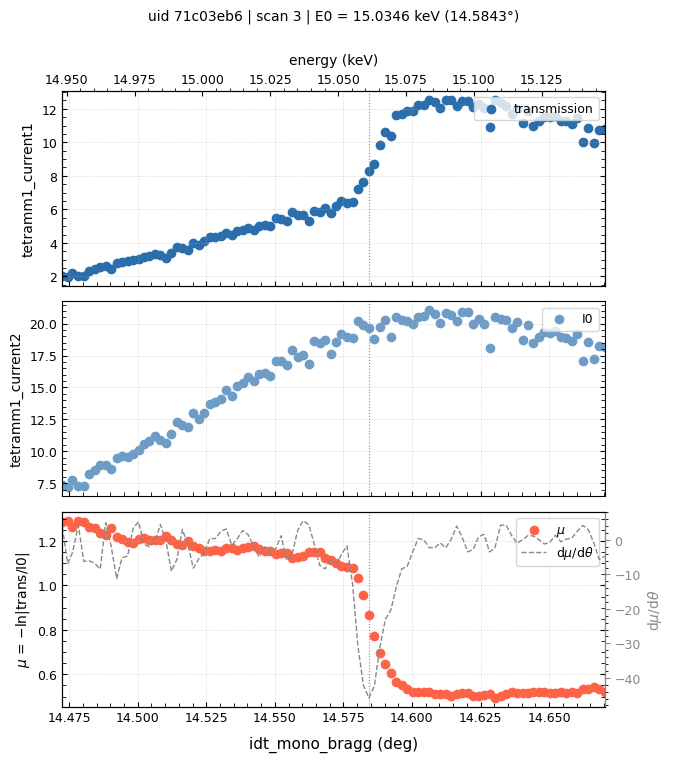

In [71]:
catalog = databroker.catalog["8idi_xpcs"]

runs_uids = list(catalog.search({}))

for uid in runs_uids[0:1]:
    run = catalog[uid]
    start = run.metadata["start"]
    t = start.get("time", 0)
    dt = datetime.fromtimestamp(t).strftime("%Y-%m-%d %H:%M:%S") if t else "?"
    print(
        uid[:],
        str(start.get("scan_id","?")).rjust(4),
        dt,
        start.get("plan_name","unknown"),
        start.get("detectors", []),
    )

run = catalog[uid]
ds = run.primary.read()

# fig, axes = plot_transmission(ds, scan_axis='idt_mono_energy')
fig, axes = plot_transmission(ds, scan_axis='idt_mono_bragg')
plt.show()

# print(ds)

In [11]:
catalog = databroker.catalog["8idi_xpcs"]

runs_uids = list(catalog.search({}))

for uid in runs_uids[0:10]:
    run = catalog[uid]
    start = run.metadata["start"]
    t = start.get("time", 0)
    dt = datetime.fromtimestamp(t).strftime("%Y-%m-%d %H:%M:%S") if t else "?"
    print(
        uid[:],
        str(start.get("scan_id","?")).rjust(4),
        dt,
        start.get("plan_name","unknown"),
        start.get("detectors", []),
    )

11437cd2-1bbd-4531-bdc9-e913b5e38df0   16 2026-03-17 13:22:26 scan ['tetramm1']
e46af5d1-f896-47d6-b706-40ce5e66ccff   15 2026-03-17 13:20:13 scan ['tetramm1']
9ab2de5a-2875-4015-82ac-3efee6dd3c17   14 2026-03-17 13:18:45 scan ['tetramm1']
bc95ca74-63fc-4113-a5a0-4887886b6381   13 2026-03-17 13:17:53 scan ['tetramm1']
e9ca17db-809c-416b-af83-d3993fea9b4e   12 2026-03-17 13:16:17 scan ['tetramm1']
a73f1d0e-4d6d-4137-9af4-5bbe0d7f708c   11 2026-03-17 13:13:15 scan ['tetramm1']
6db24c87-8e96-42f2-af88-92108a22d5b3   10 2026-03-17 13:05:49 scan ['tetramm1']
99bb0302-e556-4f5b-8d86-d8c7990929f2    9 2026-03-17 13:04:15 scan ['tetramm1']
6e451913-34ad-47a5-83d3-f56cd46e48e7    8 2026-03-17 13:00:46 scan ['tetramm1']
5d1675b3-561e-4e56-bc98-39aa5d8ad027    7 2026-03-17 12:59:43 scan ['tetramm1']


energy:  [14.99089888 14.99215255 14.99224429 14.99404876 14.99407934 14.99410993
 14.9968328  14.9969552  14.9969858  14.99974035 14.99989341 14.99992403
 14.99998525 15.00399667 15.00488499 15.00497689 15.0069071  15.00702967
 15.00886847 15.00892977 15.00896042 15.01193417 15.01208749 15.01211815
 15.01187284 15.01184218 15.01717952 15.01724089 15.01727158 15.01705678
 15.01702609 15.02212159 15.02221371 15.0237185  15.02390278 15.0239335
 15.02691339 15.02706702 15.02709775 15.02961785 15.0298945  15.03195433
 15.03204657 15.0338302  15.03395323 15.03592191 15.03604497 15.03607574
 15.03610651 15.03589115 15.03582962 15.04223145 15.04226224 15.04232383
 15.04460279 15.0448184  15.04491081 15.04774523 15.04789931 15.05005672
 15.05018002 15.05150563 15.05184477 15.05246145 15.05406504 15.05412672
 15.05384915 15.05816814 15.05826072 15.05964952 15.05986558 15.05992732
 15.05995818 15.06391019 15.06400284 15.06403372 15.06672112 15.06690649
 15.06696829 15.0697804  15.06990403 15.069

/tmp/ipykernel_42983/2949356226.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


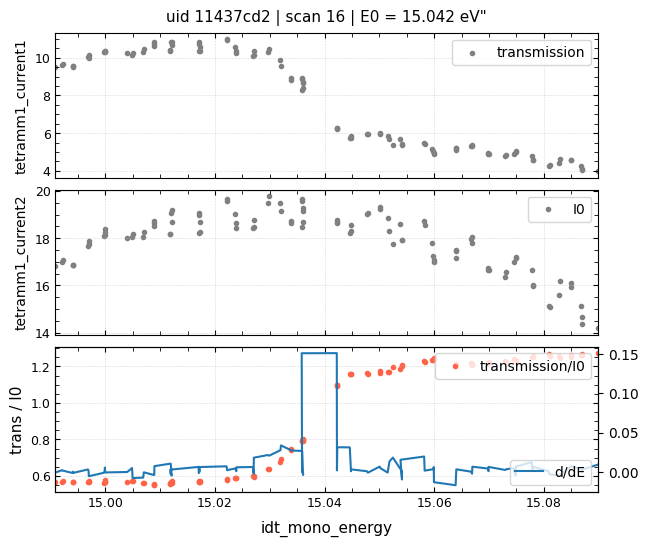

In [44]:
uid = '11437cd2-1bbd-4531-bdc9-e913b5e38df0'
run = catalog[uid]
ds = run.primary.read()
# print(json.dumps(dict(run.metadata["start"]), indent=2, default=str))
list(run)
fig, axes = plot_transmission(ds, scan_axis='idt_mono_energy')
plt.show()

In [ ]:
print("Streams:", list(run))
bl = run.baseline.read()
print(bl)
# bl['idt_mono_bragg']


Streams: ['label_start_motor', 'primary', 'baseline']
<xarray.Dataset> Size: 272B
Dimensions:                              (time: 2)
Coordinates:
  * time                                 (time) float64 16B 1.774e+09 1.774e+09
Data variables: (12/16)
    idt_mono_bragg                       (time) float64 16B 14.57 14.67
    idt_mono_bragg_user_setpoint         (time) float64 16B 14.57 14.67
    idt_mono_xtal_gap                    (time) float64 16B 5.03 5.03
    idt_mono_xtal_gap_user_setpoint      (time) float64 16B 5.03 5.03
    idt_mono_flag                        (time) float64 16B 27.0 27.0
    idt_mono_flag_user_setpoint          (time) float64 16B 27.0 27.0
    ...                                   ...
    idt_mono_x_slide                     (time) float64 16B 51.19 51.19
    idt_mono_x_slide_user_setpoint       (time) float64 16B 51.19 51.19
    idt_mono_y_slide                     (time) float64 16B 5.3 5.3
    idt_mono_y_slide_user_setpoint       (time) float64 16B 5.3 5.3


In [ ]:
def plot_transmission(ds, scan_axis='idt_mono_bragg',
                      trans_ch='tetramm1_current1_mean_value',
                      i0_ch='tetramm1_current2_mean_value',
                      silicon=311):

    theta = np.array(ds[scan_axis][1:])
    energy = bragg_to_energy(theta, silicon=silicon)

    if scan_axis == 'idt_mono_bragg':
        x     = theta
        x_top = energy
    else:
        x     = np.array(ds[scan_axis][1:])
        x_top = None

    scan_num = run.metadata["start"]["scan_id"]
    trans = np.array(ds[trans_ch][1:])
    I0    = np.array(ds[i0_ch][1:])

    n = min(len(x), len(trans), len(I0))
    x, trans, I0 = x[:n], trans[:n], I0[:n]
    if x_top is not None:
        x_top = x_top[:n]

    norm = trans / I0
    mu   = -np.log(np.abs(norm))
    dmu  = np.gradient(mu, x)

    e_edge_idx = np.argmax(np.abs(dmu))
    e_edge_deg = x[e_edge_idx]
    e_edge_kev = x_top[e_edge_idx] if x_top is not None else None

    fig = plt.figure(figsize=(7, 8))
    gs  = fig.add_gridspec(3, 1, hspace=0.08)

    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1], sharex=ax0)
    ax2 = fig.add_subplot(gs[2], sharex=ax0)
    ax3 = ax2.twinx()

    if x_top is not None:
        ax0_top = ax0.twiny()
        ax0_top.set_xlim(x_top.min(), x_top.max())
        ax0_top.set_xlabel('energy (keV)', fontsize=10, labelpad=6)
        ax0_top.tick_params(axis='x', labelsize=9, direction='in')
        ax0_top.xaxis.set_minor_locator(ticker.AutoMinorLocator())

    sk = dict(marker='.', s=8, zorder=3)
    ax0.scatter(x, trans, color="#7ea2c1", label='transmission',)
    ax1.scatter(x, I0,   color="#6d9cc6", label='I0')
    ax2.scatter(x, mu,   color='tomato',  label=r'$\mu$')
    ax3.plot(x, dmu,     color='#888',    linewidth=1.0, linestyle='--', label=r'd$\mu$/d$\theta$')

    ax0.axvline(e_edge_deg, color='#888', linewidth=0.8, linestyle=':')
    ax1.axvline(e_edge_deg, color='#888', linewidth=0.8, linestyle=':')
    ax2.axvline(e_edge_deg, color='#888', linewidth=0.8, linestyle=':')

    ax0.set_ylabel(trans_ch.split('_mean')[0], fontsize=10)
    ax1.set_ylabel(i0_ch.split('_mean')[0],    fontsize=10)
    ax2.set_ylabel(r'$\mu$ = $-\ln|$trans/I0$|$', fontsize=10)
    ax3.set_ylabel(r'd$\mu$/d$\theta$', fontsize=10, color='#888')
    ax2.set_xlabel('idt_mono_bragg (deg)', fontsize=11, labelpad=8)

    lines  = ax2.collections[:] + ax3.get_lines()
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc='upper right', fontsize=9)
    ax0.legend(loc='upper right', fontsize=9)
    ax1.legend(loc='upper right', fontsize=9)

    for ax in [ax0, ax1, ax2]:
        ax.tick_params(axis='both', labelsize=9, direction='in', top=False, right=True)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.tick_params(which='minor', direction='in', right=True, length=3)
        ax.spines[:].set_linewidth(0.8)
        ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5, zorder=0)
        ax.set_xlim(x.min(), x.max())

    ax3.tick_params(axis='y', labelsize=9, colors='#888')
    ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax3.spines['right'].set_linewidth(0.8)
    ax3.spines['right'].set_color('#888')

    plt.setp(ax0.get_xticklabels(), visible=False)
    plt.setp(ax1.get_xticklabels(), visible=False)

    title = f'uid {uid[:8]} | scan {scan_num}'
    if e_edge_kev is not None:
        title += f' | E0 = {e_edge_kev:.4f} keV ({e_edge_deg:.4f}°)'
    ax0.set_title(title, fontsize=10, pad=24, loc='center')

    fig.tight_layout()
    return fig, (ax0, ax1, ax2, ax3)